# Pretrained KPN inference from per-phase correlation NPY files

이 노트북은 `Burst Denoising with Kernel Prediction Networks` 논문과 현재 PyTorch 저장소를 기준으로 만든 **추론 전용** 파이프라인입니다. 학습이나 노이즈 생성을 수행하지 않습니다.

입력 가정:

- Google Drive의 `datasets/C0.zip`, `C1.zip`, `C2.zip`, `C3.zip`에 phase별 데이터가 존재
- 각 phase에는 `raw_0001.npy` ~ `raw_0010.npy` noisy correlation frame이 존재
- 각 `sigma_XXXX.npy`는 대응 raw frame의 픽셀별 예상 noise 표준편차 `[H,W]`
- 모든 raw frame과 sigma map은 동일한 correlation 단위를 사용

각 phase의 10개 raw frame 전체에서 하나의 global maximum을 계산합니다. raw와 sigma를 이 값으로 함께 정규화한 뒤 `raw_0001.npy` ~ `raw_0008.npy`만 pretrained 8-frame 모델에 입력합니다. reference는 `raw_0001.npy`, noise map은 `sigma_0001.npy`입니다. `SIGMA_MAP_SCALE`로 선택된 sigma map의 배율을 조절할 수 있으며 기본값 `0.5`는 원본 sigma map의 절반을 사용합니다. 출력에는 같은 phase scale을 다시 곱해 원래 correlation 단위로 복원합니다.


## 1. Google Drive 마운트

In [1]:
from google.colab import drive

drive.mount("/content/drive", force_remount=False)

Mounted at /content/drive


## 2. 사용자 설정

`DATASET_ZIP_PATHS`는 Drive에 저장한 phase별 ZIP 경로입니다. `PHASES`에 지정한 ZIP만 Colab의 `/content`로 복사하여 압축 해제합니다. 각 phase scale은 해당 phase의 10개 raw frame 전체에서 계산한 global maximum입니다.

In [ ]:
# Git repository
REPO_URL = "https://github.com/dohee02/kernel-prediction-networks-PyTorch.git"
GIT_REF = "experiment/colab"  # branch, tag, 또는 commit SHA
REPO_DIR = "/content/kpn_repo"

# Official pretrained checkpoint from this repository's README
OFFICIAL_CKPT_FILE_ID = "1Xnpllr1dinAU7BIN21L3LkEP5AqMNWso"
CHECKPOINT_PATH = "/content/drive/MyDrive/kpn_models/model_best.pth.tar"
DOWNLOAD_OFFICIAL_IF_MISSING = True

# Input/output paths
DATASET_ZIP_PATHS = {
    phase: f"/content/drive/MyDrive/kpn/datasets/{phase}.zip"
    for phase in ("C0", "C1", "C2", "C3")
}
LOCAL_DATASET_CACHE = "/content/kpn_dataset_cache"
OUTPUT_DIR = "/content/drive/MyDrive/kpn/outputs-std05"

# Per-phase input policy
PHASES = ("C0", "C1", "C2", "C3")
#PHASES = ("C0",)
EXPECTED_FRAME_COUNT = 10
REFERENCE_INDEX = 0  # raw_0001.npy
BLACK_LEVEL = 0.0
NOISE_MAP_KIND = "std"  # "std" 또는 "variance"
SIGMA_MAP_SCALE = 1.0  # 0.5: sigma map의 절반, 1.0: 원본 그대로 사용
STRICT_FILE_COUNT = True

## 3. 사용자 GitHub 저장소 가져오기

원격 branch를 가져온 뒤 detached 상태로 checkout합니다. 로컬에서 수정한 코드를 사용하려면 먼저 해당 branch에 commit/push해야 합니다. 이미 `/content/kpn_repo`가 있다면 그 clone을 재사용하며, 강제 삭제나 reset은 하지 않습니다.

In [3]:
from pathlib import Path
import subprocess

repo_dir = Path(REPO_DIR)

def run_command(args, cwd=None):
    result = subprocess.run(
        args, cwd=cwd, check=True, text=True,
        stdout=subprocess.PIPE, stderr=subprocess.STDOUT,
    )
    if result.stdout.strip():
        print(result.stdout.strip())
    return result

if not (repo_dir / ".git").is_dir():
    if repo_dir.exists():
        raise RuntimeError(f"{repo_dir} exists but is not a Git repository. Move or remove it first.")
    run_command(["git", "clone", REPO_URL, str(repo_dir)])

run_command(["git", "fetch", "origin", "--tags"], cwd=repo_dir)
remote_ref = f"origin/{GIT_REF}"
remote_exists = subprocess.run(
    ["git", "rev-parse", "--verify", remote_ref],
    cwd=repo_dir, stdout=subprocess.DEVNULL, stderr=subprocess.DEVNULL,
).returncode == 0
checkout_target = remote_ref if remote_exists else GIT_REF
run_command(["git", "checkout", "--detach", checkout_target], cwd=repo_dir)
commit = run_command(["git", "rev-parse", "HEAD"], cwd=repo_dir).stdout.strip()
print(f"Using commit: {commit}")

Cloning into '/content/kpn_repo'...
HEAD is now at aa3994c update kpn ipynb std scaling
aa3994c3a84b2921e92d50639a60290840d3da12
Using commit: aa3994c3a84b2921e92d50639a60290840d3da12


## 4. 추론에 필요한 패키지 설치

Colab에 설치된 GPU용 PyTorch를 그대로 사용하고, 현재 저장소가 import 시 요구하는 최소 패키지만 추가합니다.

In [4]:
%pip install -q configobj torchsummary gdown

## 5. Pretrained checkpoint 준비

Drive에 체크포인트가 이미 있으면 재사용합니다. 없고 다운로드 옵션이 켜져 있으면 원본 README에 기재된 pretrained 파일을 내려받습니다. 체크포인트는 신뢰할 수 있는 출처의 파일만 사용하세요.

In [5]:
from pathlib import Path
import gdown

checkpoint_path = Path(CHECKPOINT_PATH)
checkpoint_path.parent.mkdir(parents=True, exist_ok=True)

if not checkpoint_path.is_file():
    if not DOWNLOAD_OFFICIAL_IF_MISSING:
        raise FileNotFoundError(f"Checkpoint not found: {checkpoint_path}")
    print("Downloading the official pretrained checkpoint...")
    downloaded = gdown.download(
        id=OFFICIAL_CKPT_FILE_ID, output=str(checkpoint_path), quiet=False,
    )
    if downloaded is None:
        raise RuntimeError("Checkpoint download failed. Upload it to Drive and rerun this cell.")

print(f"Checkpoint: {checkpoint_path} ({checkpoint_path.stat().st_size / 2**20:.1f} MiB)")

Checkpoint: /content/drive/MyDrive/kpn_models/model_best.pth.tar (329.0 MiB)


## 6. 저장소 설정으로 KPN 생성 및 pretrained weight 로드

현재 pretrained 설정은 흑백(`color=False`), 8-frame, noise-aware(`blind_est=False`) 모델입니다. 과거 multi-GPU 학습 체크포인트에 붙은 `module.` prefix는 메모리에서 제거한 뒤 strict하게 로드합니다.

In [6]:
import sys
import numpy as np
import torch
from configobj import ConfigObj

if REPO_DIR not in sys.path:
    sys.path.insert(0, REPO_DIR)

from KPN import KPN

def as_bool(value):
    if isinstance(value, bool):
        return value
    return str(value).strip().lower() in {"1", "true", "yes", "on"}

repo_path = Path(REPO_DIR)
config = ConfigObj(str(repo_path / "kpn_specs/kpn_config.conf"))
arch = config["architecture"]
training = config["training"]
dataset_config = ConfigObj(str(repo_path / training["dataset_configs"]))
dataset = dataset_config["dataset_configs"]

BURST_SIZE = int(dataset["burst_length"])
BLIND_EST = as_bool(arch.get("blind_est", False))
KERNEL_SIZES = [int(v) for v in str(arch["kernel_size"]).split()]

if BURST_SIZE != 8:
    raise ValueError(f"This notebook expects the official 8-frame checkpoint, config has {BURST_SIZE}.")
if BLIND_EST:
    raise ValueError("The selected config is blind, but this notebook is for a known noise map.")

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = KPN(
    color=False,
    burst_length=BURST_SIZE,
    blind_est=BLIND_EST,
    kernel_size=KERNEL_SIZES,
    sep_conv=as_bool(arch.get("sep_conv", False)),
    channel_att=as_bool(arch.get("channel_att", False)),
    spatial_att=as_bool(arch.get("spatial_att", False)),
    upMode=arch.get("upMode", "bilinear"),
    core_bias=as_bool(arch.get("core_bias", False)),
).to(device)

try:
    checkpoint = torch.load(checkpoint_path, map_location="cpu", weights_only=False)
except TypeError:  # older PyTorch
    checkpoint = torch.load(checkpoint_path, map_location="cpu")

state_dict = checkpoint.get("state_dict", checkpoint)
state_dict = {
    (key[7:] if key.startswith("module.") else key): value
    for key, value in state_dict.items()
}
model.load_state_dict(state_dict, strict=True)
model.eval()

print(f"Device: {device}")
print(f"Model input: {BURST_SIZE} grayscale frames + 1 known noise map")
print(f"Kernel sizes: {KERNEL_SIZES}")
if isinstance(checkpoint, dict):
    print(f"Checkpoint epoch={checkpoint.get('epoch', '?')}, iter={checkpoint.get('global_iter', '?')}")

Device: cuda
Model input: 8 grayscale frames + 1 known noise map
Kernel sizes: [5]
Checkpoint epoch=245, iter=77600


## 7. Phase별 correlation frame과 noise map 로드

Drive의 ZIP을 Colab 로컬 캐시로 복사하고 `PHASES`에 지정한 phase만 압축 해제합니다. 그 다음 각 phase에서 10개의 `raw_*.npy`를 `[10,H,W]`로 stack하고, 10장 전체의 global maximum을 phase scale로 계산합니다. 모델에는 앞의 8장만 입력하며 `raw_0001.npy`를 reference로 사용합니다.

선택한 sigma map에는 `SIGMA_MAP_SCALE`을 먼저 곱합니다. 그 다음 raw와 noise 표준편차를 같은 phase scale로 나눕니다. `NOISE_MAP_KIND="std"`일 때는 `sigma_norm = (sigma * SIGMA_MAP_SCALE) / phase_scale`이며 `sqrt(raw_norm)`을 새로 계산하지 않습니다.

In [7]:
from pathlib import Path, PurePosixPath
import shutil
import zipfile
import numpy as np

if isinstance(PHASES, str) or not PHASES:
    raise TypeError("PHASES must be a non-empty tuple/list, for example ('C0',).")
if NOISE_MAP_KIND not in {"std", "variance"}:
    raise ValueError("NOISE_MAP_KIND must be 'std' or 'variance'.")
if not np.isfinite(SIGMA_MAP_SCALE) or SIGMA_MAP_SCALE < 0:
    raise ValueError("SIGMA_MAP_SCALE must be a finite, non-negative number.")
if EXPECTED_FRAME_COUNT < BURST_SIZE:
    raise ValueError("EXPECTED_FRAME_COUNT must be at least the model burst size.")
if not (0 <= REFERENCE_INDEX < BURST_SIZE):
    raise ValueError("REFERENCE_INDEX must select one of the first 8 frames.")

cache_root = Path(LOCAL_DATASET_CACHE)
cache_root.mkdir(parents=True, exist_ok=True)
phase_directories = {}
for phase_name in PHASES:
    if phase_name not in DATASET_ZIP_PATHS:
        raise KeyError(f"No dataset ZIP configured for phase {phase_name}.")
    zip_source = Path(DATASET_ZIP_PATHS[phase_name])
    if not zip_source.is_file():
        raise FileNotFoundError(f"Dataset ZIP not found: {zip_source}")

    local_zip = cache_root / zip_source.name
    shutil.copy2(zip_source, local_zip)
    zip_stat = local_zip.stat()
    extract_root = cache_root / f"extracted_{phase_name}_{zip_stat.st_size}_{zip_stat.st_mtime_ns}"
    extract_root.mkdir(parents=True, exist_ok=True)

    with zipfile.ZipFile(local_zip, "r") as archive:
        for member in archive.infolist():
            normalized_name = member.filename.replace("\\", "/")
            member_path = PurePosixPath(normalized_name)
            if member_path.is_absolute() or ".." in member_path.parts:
                raise ValueError(f"Unsafe path in ZIP: {member.filename}")
        archive.extractall(extract_root)

    candidates = [
        path for path in (extract_root, *extract_root.rglob("*"))
        if path.is_dir() and any(path.glob("raw_*.npy"))
    ]
    if len(candidates) != 1:
        raise RuntimeError(
            f"Expected one extracted directory for {phase_name}, found {candidates}."
        )
    phase_directories[phase_name] = candidates[0]
    print(f"Copied {phase_name} dataset ZIP to: {local_zip}")
    print(f"Extracted {phase_name} dataset to: {phase_directories[phase_name]}")

def load_2d_npy(path):
    array = np.load(path, allow_pickle=False)
    if array.ndim == 3 and array.shape[0] == 1:
        array = array[0]
    elif array.ndim == 3 and array.shape[-1] == 1:
        array = array[..., 0]
    if array.ndim != 2:
        raise ValueError(f"Expected a 2-D grayscale array in {path}, got {array.shape}.")
    array = array.astype(np.float32, copy=False)
    if not np.isfinite(array).all():
        raise ValueError(f"NaN or Inf found in {path}.")
    return array

def load_phase(phase_name):
    phase_dir = phase_directories[phase_name]
    if not phase_dir.is_dir():
        raise FileNotFoundError(f"Phase directory not found: {phase_dir}")

    raw_paths = [phase_dir / f"raw_{index:04d}.npy" for index in range(1, EXPECTED_FRAME_COUNT + 1)]
    sigma_paths = [phase_dir / f"sigma_{index:04d}.npy" for index in range(1, EXPECTED_FRAME_COUNT + 1)]
    missing = [path.name for path in raw_paths + sigma_paths if not path.is_file()]
    if missing:
        raise FileNotFoundError(f"{phase_name}: missing expected files: {missing}")

    if STRICT_FILE_COUNT:
        actual_raw = sorted(phase_dir.glob("raw_*.npy"))
        actual_sigma = sorted(phase_dir.glob("sigma_*.npy"))
        if actual_raw != raw_paths or actual_sigma != sigma_paths:
            raise ValueError(
                f"{phase_name}: expected exactly {EXPECTED_FRAME_COUNT} raw/sigma pairs; "
                f"found raw={len(actual_raw)}, sigma={len(actual_sigma)}."
            )

    raw_all = np.stack([load_2d_npy(path) for path in raw_paths], axis=0)
    signal_all = raw_all - float(BLACK_LEVEL)
    phase_scale = float(np.max(signal_all))
    if not np.isfinite(phase_scale) or phase_scale <= 0:
        raise ValueError(f"{phase_name}: invalid phase global maximum {phase_scale}.")

    selected_indices = list(range(BURST_SIZE))
    model_order = [REFERENCE_INDEX] + [index for index in selected_indices if index != REFERENCE_INDEX]
    selected_signal = signal_all[model_order]
    below_zero_fraction = float(np.mean(selected_signal < 0))
    burst_norm = np.clip(selected_signal / phase_scale, 0.0, 1.0).astype(np.float32)

    noise_source = load_2d_npy(sigma_paths[REFERENCE_INDEX]) * float(SIGMA_MAP_SCALE)
    if noise_source.shape != raw_all.shape[1:]:
        raise ValueError(
            f"{phase_name}: raw/noise shape mismatch: {raw_all.shape[1:]} vs {noise_source.shape}."
        )
    if np.any(noise_source < 0):
        raise ValueError(f"{phase_name}: a noise std/variance map cannot contain negative values.")
    noise_std = np.sqrt(noise_source) if NOISE_MAP_KIND == "variance" else noise_source
    noise_norm = (noise_std / phase_scale).astype(np.float32)

    return {
        "phase_dir": phase_dir,
        "raw_paths": raw_paths,
        "sigma_path": sigma_paths[REFERENCE_INDEX],
        "raw_shape_10hw": raw_all.shape,
        "model_order": model_order,
        "burst_norm": burst_norm,
        "noise_norm": noise_norm,
        "phase_scale": phase_scale,
        "below_zero_fraction": below_zero_fraction,
    }

phase_inputs = {phase_name: load_phase(phase_name) for phase_name in PHASES}
for phase_name, phase_data in phase_inputs.items():
    print(
        f"{phase_name}: loaded={phase_data['raw_shape_10hw']}, "
        f"model_input={phase_data['burst_norm'].shape}, "
        f"global_max={phase_data['phase_scale']:.9g}, "
        f"sigma_scale={SIGMA_MAP_SCALE:g}, "
        f"noise=[{phase_data['noise_norm'].min():.6g}, {phase_data['noise_norm'].max():.6g}], "
        f"below_zero={100 * phase_data['below_zero_fraction']:.3f}%"
    )

Copied C0 dataset ZIP to: /content/kpn_dataset_cache/C0.zip
Extracted C0 dataset to: /content/kpn_dataset_cache/extracted_C0_13249018_1788429593000000000
Copied C1 dataset ZIP to: /content/kpn_dataset_cache/C1.zip
Extracted C1 dataset to: /content/kpn_dataset_cache/extracted_C1_13281008_1788429603000000000
Copied C2 dataset ZIP to: /content/kpn_dataset_cache/C2.zip
Extracted C2 dataset to: /content/kpn_dataset_cache/extracted_C2_13189470_1788429606000000000
Copied C3 dataset ZIP to: /content/kpn_dataset_cache/C3.zip
Extracted C3 dataset to: /content/kpn_dataset_cache/extracted_C3_13237878_1788429588000000000
C0: loaded=(10, 480, 640), model_input=(8, 480, 640), global_max=1135.52673, sigma_scale=0.5, noise=[0.0019216, 0.0148379], below_zero=0.000%
C1: loaded=(10, 480, 640), model_input=(8, 480, 640), global_max=1383.06689, sigma_scale=0.5, noise=[0.000324215, 0.0134446], below_zero=0.000%
C2: loaded=(10, 480, 640), model_input=(8, 480, 640), global_max=761.211731, sigma_scale=0.5, nois

## 8. Pretrained 8-frame 입력 확인

각 phase의 scale은 10장 전체에서 계산하지만 모델 입력은 `raw_0001.npy` ~ `raw_0008.npy`로 고정합니다. 기본 reference는 첫 파일이며, reference noise map도 동일한 번호의 sigma 파일을 사용합니다. 현재 `SIGMA_MAP_SCALE=0.5`이므로 로드한 reference sigma map의 각 값에 0.5를 곱해 모델에 전달합니다.

In [8]:
for phase_name, phase_data in phase_inputs.items():
    selected_files = [phase_data['raw_paths'][index].name for index in phase_data['model_order']]
    print(f"{phase_name}: frames={selected_files}")
    print(f"{phase_name}: reference_noise={phase_data['sigma_path'].name}")

C0: frames=['raw_0001.npy', 'raw_0002.npy', 'raw_0003.npy', 'raw_0004.npy', 'raw_0005.npy', 'raw_0006.npy', 'raw_0007.npy', 'raw_0008.npy']
C0: reference_noise=sigma_0001.npy
C1: frames=['raw_0001.npy', 'raw_0002.npy', 'raw_0003.npy', 'raw_0004.npy', 'raw_0005.npy', 'raw_0006.npy', 'raw_0007.npy', 'raw_0008.npy']
C1: reference_noise=sigma_0001.npy
C2: frames=['raw_0001.npy', 'raw_0002.npy', 'raw_0003.npy', 'raw_0004.npy', 'raw_0005.npy', 'raw_0006.npy', 'raw_0007.npy', 'raw_0008.npy']
C2: reference_noise=sigma_0001.npy
C3: frames=['raw_0001.npy', 'raw_0002.npy', 'raw_0003.npy', 'raw_0004.npy', 'raw_0005.npy', 'raw_0006.npy', 'raw_0007.npy', 'raw_0008.npy']
C3: reference_noise=sigma_0001.npy


## 9. KPN 추론

KPN encoder/decoder의 downsampling 크기를 맞추기 위해 오른쪽과 아래쪽을 16의 배수까지 padding하고, 추론 후 원래 크기로 자릅니다. resize는 하지 않습니다. 큰 해상도에서는 GPU 메모리가 부족할 수 있으며, 그런 경우 overlap tile 추론을 별도로 추가해야 합니다.

In [9]:
import torch.nn.functional as F

def pad_to_multiple(tensor, multiple=16):
    height, width = tensor.shape[-2:]
    pad_h = (-height) % multiple
    pad_w = (-width) % multiple
    if pad_h == 0 and pad_w == 0:
        return tensor, (height, width)
    mode = "reflect" if pad_h < height and pad_w < width else "replicate"
    return F.pad(tensor, (0, pad_w, 0, pad_h), mode=mode), (height, width)

phase_predictions = {}

for phase_name, phase_data in phase_inputs.items():
    burst_tensor = torch.from_numpy(phase_data['burst_norm']).unsqueeze(0).to(device)
    noise_tensor = torch.from_numpy(phase_data['noise_norm']).unsqueeze(0).unsqueeze(0).to(device)
    model_input = torch.cat([burst_tensor, noise_tensor], dim=1)  # [1,9,H,W]

    model_input_pad, original_hw = pad_to_multiple(model_input, multiple=16)
    burst_pad = model_input_pad[:, :BURST_SIZE, ...]
    white_level = torch.ones((1, 1, 1, 1), dtype=model_input_pad.dtype, device=device)

    with torch.inference_mode():
        _, prediction = model(model_input_pad, burst_pad, white_level)

    height, width = original_hw
    prediction_array = prediction.detach().float().cpu().numpy()
    if prediction_array.ndim >= 3 and prediction_array.shape[0] == 1:
        prediction_array = prediction_array[0]
    if prediction_array.ndim == 3 and prediction_array.shape[0] == 1:
        prediction_array = prediction_array[0]
    if prediction_array.ndim != 2:
        raise RuntimeError(f"{phase_name}: unexpected model output shape {prediction_array.shape}.")

    denoised_norm = np.clip(prediction_array[:height, :width], 0.0, 1.0).astype(np.float32)
    denoised_correlation = (denoised_norm * phase_data['phase_scale']).astype(np.float32)
    phase_predictions[phase_name] = {
        "normalized": denoised_norm,
        "correlation": denoised_correlation,
    }
    print(
        f"{phase_name}: output={denoised_norm.shape}, "
        f"normalized=[{denoised_norm.min():.6g}, {denoised_norm.max():.6g}], "
        f"correlation=[{denoised_correlation.min():.6g}, {denoised_correlation.max():.6g}]"
    )

C0: output=(480, 640), normalized=[0.0115212, 1], correlation=[13.0826, 1135.53]
C1: output=(480, 640), normalized=[9.2609e-05, 1], correlation=[0.128084, 1383.07]
C2: output=(480, 640), normalized=[0.000430549, 1], correlation=[0.327739, 761.212]
C3: output=(480, 640), normalized=[0, 1], correlation=[0, 513.672]


## 10. 결과 저장 및 시각화

각 phase의 결과를 별도 디렉터리에 저장합니다. `denoised_normalized.npy`는 `[0,1]` 정규화 결과이고, `denoised_correlation.npy`는 해당 phase global maximum을 다시 곱한 원래 correlation 단위 결과입니다. PNG는 단순 확인용이며 정량 분석에는 `.npy`를 사용하세요.

/tmp/ipykernel_1121/3700536812.py:23: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  Image.fromarray(preview, mode="L").save(phase_output_dir / "denoised_preview.png")


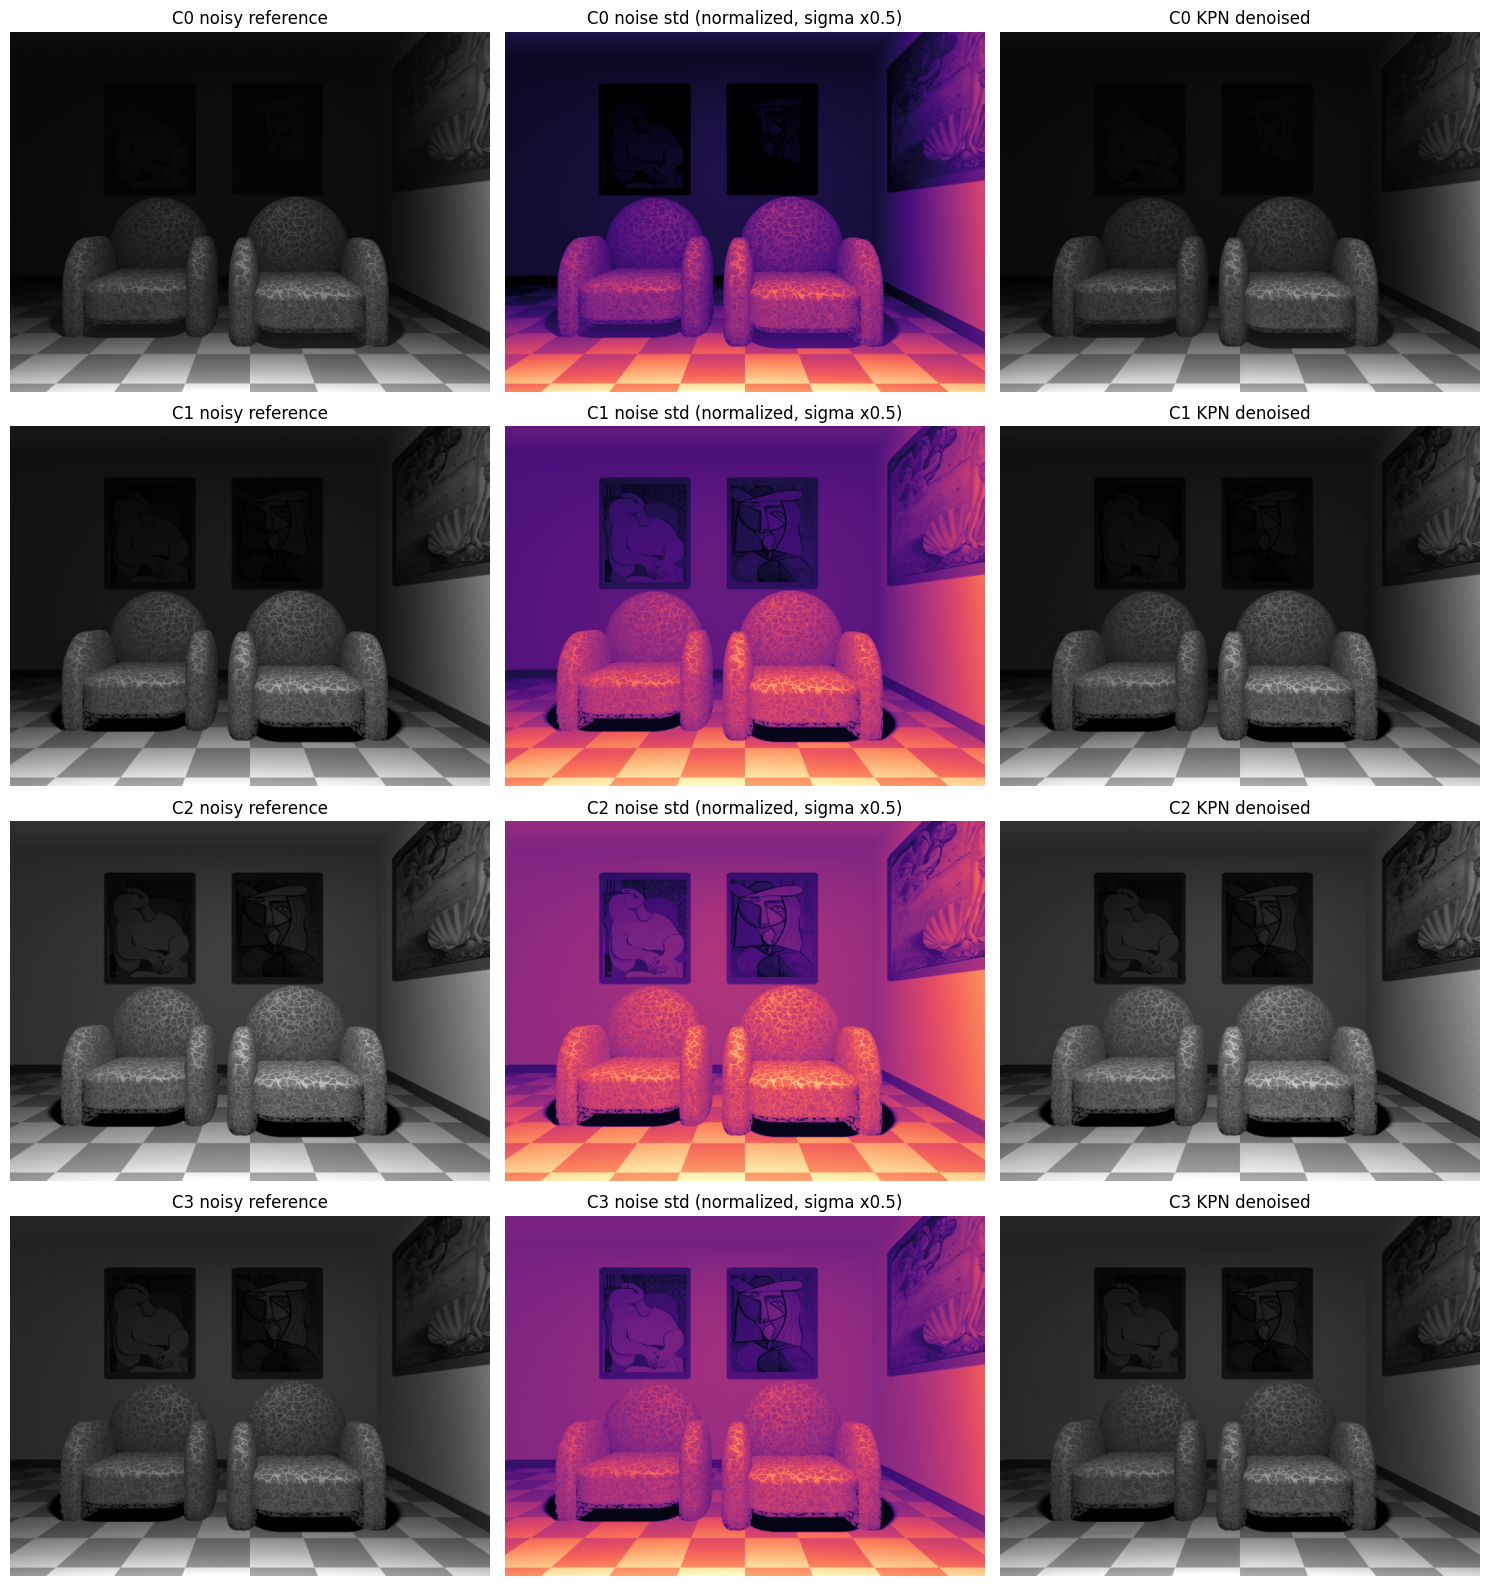

Saved phase results to: /content/drive/MyDrive/kpn/outputs-std05


In [10]:
from pathlib import Path
import json
import matplotlib.pyplot as plt
from PIL import Image

output_root = Path(OUTPUT_DIR)
output_root.mkdir(parents=True, exist_ok=True)

figure, axes = plt.subplots(len(PHASES), 3, figsize=(15, 4 * len(PHASES)), squeeze=False)

for row, phase_name in enumerate(PHASES):
    phase_data = phase_inputs[phase_name]
    prediction_data = phase_predictions[phase_name]
    phase_output_dir = output_root / phase_name
    phase_output_dir.mkdir(parents=True, exist_ok=True)

    denoised_norm = prediction_data['normalized']
    denoised_correlation = prediction_data['correlation']
    np.save(phase_output_dir / "denoised_normalized.npy", denoised_norm)
    np.save(phase_output_dir / "denoised_correlation.npy", denoised_correlation)

    preview = (np.clip(denoised_norm, 0.0, 1.0) * 255.0 + 0.5).astype(np.uint8)
    Image.fromarray(preview, mode="L").save(phase_output_dir / "denoised_preview.png")

    selected_raw_paths = [phase_data['raw_paths'][index] for index in phase_data['model_order']]
    run_info = {
        "phase": phase_name,
        "repository": REPO_URL,
        "git_ref": GIT_REF,
        "commit": commit,
        "checkpoint": str(checkpoint_path),
        "phase_directory": str(phase_data['phase_dir']),
        "all_raw_files_for_scale": [str(path) for path in phase_data['raw_paths']],
        "selected_raw_files": [str(path) for path in selected_raw_paths],
        "reference_index_zero_based": int(REFERENCE_INDEX),
        "reference_noise_map": str(phase_data['sigma_path']),
        "input_shape_8hw": list(phase_data['burst_norm'].shape),
        "phase_global_max": float(phase_data['phase_scale']),
        "black_level": float(BLACK_LEVEL),
        "noise_map_kind": NOISE_MAP_KIND,
        "sigma_map_scale": float(SIGMA_MAP_SCALE),
        "normalization": "raw / phase_global_max; interpreted_std(sigma * sigma_map_scale) / phase_global_max",
    }
    with (phase_output_dir / "run_info.json").open("w", encoding="utf-8") as file:
        json.dump(run_info, file, ensure_ascii=False, indent=2)

    reference_norm = phase_data['burst_norm'][0]
    axes[row, 0].imshow(reference_norm, cmap="gray", vmin=0, vmax=1)
    axes[row, 0].set_title(f"{phase_name} noisy reference")
    axes[row, 1].imshow(phase_data['noise_norm'], cmap="magma")
    axes[row, 1].set_title(f"{phase_name} noise std (normalized, sigma x{SIGMA_MAP_SCALE:g})")
    axes[row, 2].imshow(denoised_norm, cmap="gray", vmin=0, vmax=1)
    axes[row, 2].set_title(f"{phase_name} KPN denoised")
    for axis in axes[row]:
        axis.axis("off")

plt.tight_layout()
figure.savefig(output_root / "phase_comparison.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved phase results to: {output_root}")

## 해석 시 주의사항

- 이 노트북은 현재 `sigma_XXXX.npy`가 해당 raw correlation frame의 올바른 noise 표준편차라고 가정하며, 선택한 map에 `SIGMA_MAP_SCALE`을 적용합니다.
- reference가 `raw_0001.npy`이면 noise map도 반드시 `sigma_0001.npy`여야 합니다.
- phase별 global max는 noisy 10-frame 데이터에 의존하는 정규화 값이며 `run_info.json`에 기록됩니다.
- 서로 다른 phase 결과를 결합할 때는 `denoised_normalized.npy`가 아니라 원래 scale로 복원된 `denoised_correlation.npy`를 사용해야 합니다.
- 모델에는 앞의 8장만 입력하므로 `raw_0009.npy`와 `raw_0010.npy`는 scale 계산에만 사용됩니다.
- pretrained checkpoint는 자연영상 RAW noise로 학습되었으므로 correlation image에 대한 성능은 별도로 검증해야 합니다.
- 논문 학습 분포와 크게 다른 noise level이나 큰 정렬 오차에서는 품질이 저하될 수 있습니다.
- GT가 없는 경우 denoising은 가능하지만 PSNR/SSIM은 계산할 수 없습니다.